In [1]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
BASE_DIR = Path().resolve().parent

# Check Plurality Voting

In [2]:
# read in df
bt_df = pd.read_csv(BASE_DIR / "Results" / "Ballots" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_ballots_BT.csv")

num_winners = 3 #We need to define this per race
num_votes = 1000 #We can calculate this but I'm too lazy to write the code for it right now

In [3]:
# Right now, rankings are a string. We can turn this into a list, seperating entries on the comma
# We want to expand this so that each vote ranking gets its own row
candidates = bt_df['ranking'].str.split(",", expand=True)

# Rename the columns
column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

# Then, combine back together
bt_df = pd.concat([candidates, bt_df.drop('ranking', axis=1)], axis=1)

In [4]:
# For checks, let's calculate the plurality winner for the first iteration just to make sure it seems right

# only keep the columns we actually want
bt_df_plur = bt_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
bt_df_plur.groupby('Vote_1').sum().reset_index().nlargest(num_winners, 'iteration_1')

,Vote_1,iteration_1
3,Ryan Patton,303.0
2,Melissa Calloway,279.0
0,Gidget Kidd,259.0


In [5]:
# Now, let's find the average over all the iterations.

In [6]:
num_iterations = len(bt_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
bt_df_plur = bt_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_bt = bt_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    bt_df_plur = bt_df[['Vote_1', f'iteration_{i}']]
    temp_df = bt_df_plur.groupby('Vote_1').sum().reset_index()
    final_bt = pd.merge(final_bt, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

In [7]:
final_bt

,Vote_1,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_91,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100
0,Gidget Kidd,259.0,273.0,212.0,228.0,198.0,242.0,235.0,308.0,234.0,...,203.0,229.0,257.0,212.0,228.0,304.0,186.0,257.0,225.0,288.0
1,Gwen Williams,115.0,182.0,172.0,171.0,163.0,152.0,143.0,186.0,145.0,...,108.0,168.0,125.0,97.0,90.0,187.0,110.0,94.0,172.0,266.0
2,Melissa Calloway,279.0,239.0,311.0,281.0,318.0,287.0,264.0,218.0,281.0,...,310.0,284.0,287.0,308.0,284.0,222.0,321.0,254.0,286.0,231.0
3,Ryan Patton,303.0,198.0,197.0,217.0,259.0,232.0,327.0,190.0,305.0,...,292.0,249.0,259.0,297.0,255.0,202.0,225.0,296.0,280.0,175.0
4,Todd Dulaney,44.0,108.0,108.0,103.0,62.0,87.0,31.0,98.0,35.0,...,87.0,70.0,72.0,86.0,143.0,85.0,158.0,99.0,37.0,40.0


In [8]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_bt = final_bt.astype({col: int for col in final_bt.columns[1:]})


In [9]:
# Plot the average percentage of votes for each candidate
final_bt = final_bt.assign(mean=final_bt.mean(axis=1, numeric_only=True))

In [10]:
final_bt['mean_perc'] = final_bt['mean']/num_votes

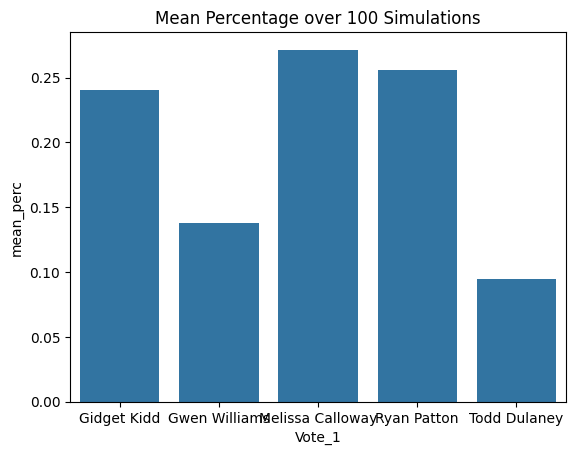

In [ ]:
# Plot the mean!
sns.barplot(final_bt, x="Vote_1", y="mean_perc")
plt.title(f"Mean Percentage over {num_iterations} Simulations")
plt.show()

# Actual Results?

In [17]:
results = pd.read_csv(BASE_DIR / "Election_Data_Sheets" / "csv" / "results_pct_20231107.csv")
results = results[results["Contest Name"] == "ASHEBORO CITY SCHOOLS BOARD OF EDUCATION"]
results = results[["Choice", "Total Votes"]]
results = results.groupby("Choice")['Total Votes'].sum().reset_index()
results = results[results["Choice"] != "Write-In (Miscellaneous)"] #Drop Write-Ins, since that's not a choice in the Simulation

Text(0.5, 1.0, 'Actual Results')

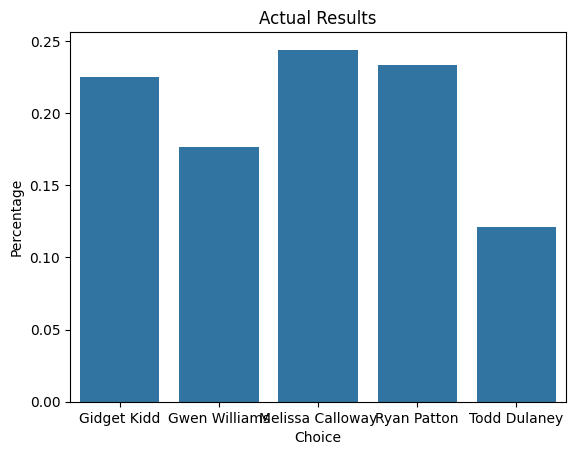

In [18]:
total_votes = results["Total Votes"].sum()
results["Percentage"] = results["Total Votes"] / total_votes
sns.barplot(results, x="Choice", y="Percentage")
plt.title("Actual Results")

In [12]:
# Does this work on Cambridge sampler too?
cam_df = pd.read_csv(BASE_DIR / "Results" / "Ballots" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_ballots_Cam.csv", skiprows=[2])

In [13]:
# Right now, rankings are a string. We can turn this into a list, seperating entries on the comma
# We want to expand this so that each vote ranking gets its own row
candidates = cam_df['ranking'].str.split(",", expand=True)

# Rename the columns
column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

# Then, combine back together
cam_df = pd.concat([candidates, cam_df.drop('ranking', axis=1)], axis=1)

In [14]:
# For checks, let's calculate the plurality winner for the first iteration just to make sure it seems right

# only keep the columns we actually want
cam_df_plur = cam_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_cam = cam_df_plur.groupby('Vote_1').sum().reset_index()

In [15]:
# only keep the columns we actually want
cam_df_plur = cam_df[['Vote_1', 'iteration_2']]
# Sum up total number of votes and get top three winners
pd.merge(final_cam, cam_df_plur.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

,Vote_1,iteration_1,iteration_2
0,Gidget Kidd,245.0,272.0
1,Gwen Williams,115.0,112.0
2,Melissa Calloway,256.0,231.0
3,Ryan Patton,255.0,179.0
4,Todd Dulaney,38.0,83.0
